In [4]:
import pandas as pd
import matplotlib.pyplot as plt 
import numpy as np 
import seaborn as sns
from sklearn.model_selection import train_test_split

In [5]:
pip install opendatasets

In [6]:
!pip install opendatasets --upgrade --quiet

import opendatasets as od
import pandas as pd
#9449f6f5009e24b903987dcc790ddd69

# Download the dataset from Kaggle URL
data=od.download("https://www.kaggle.com/datasets/logiccraftbyhimanshi/e-commerce-analytics-swiggy-zomato-blinkit")




Skipping, found downloaded files in "./e-commerce-analytics-swiggy-zomato-blinkit" (use force=True to force download)


In [7]:
# Display first few rows
data = pd.read_csv('./e-commerce-analytics-swiggy-zomato-blinkit/Ecommerce_Delivery_Analytics_New.csv')
data.head()


,Order ID,Customer ID,Platform,Order Date & Time,Delivery Time (Minutes),Product Category,Order Value (INR),Customer Feedback,Service Rating,Delivery Delay,Refund Requested
0,ORD000001,CUST2824,JioMart,19:29.5,30,Fruits & Vegetables,382,"Fast delivery, great service!",5,No,No
1,ORD000002,CUST1409,Blinkit,54:29.5,16,Dairy,279,Quick and reliable!,5,No,No
2,ORD000003,CUST5506,JioMart,21:29.5,25,Beverages,599,Items missing from order.,2,No,Yes
3,ORD000004,CUST5012,JioMart,19:29.5,42,Beverages,946,Items missing from order.,2,Yes,Yes
4,ORD000005,CUST4657,Blinkit,49:29.5,30,Beverages,334,"Fast delivery, great service!",5,No,No


In [8]:
df=data.copy()

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 11 columns):
 #   Column                   Non-Null Count   Dtype 
---  ------                   --------------   ----- 
 0   Order ID                 100000 non-null  object
 1   Customer ID              100000 non-null  object
 2   Platform                 100000 non-null  object
 3   Order Date & Time        100000 non-null  object
 4   Delivery Time (Minutes)  100000 non-null  int64 
 5   Product Category         100000 non-null  object
 6   Order Value (INR)        100000 non-null  int64 
 7   Customer Feedback        100000 non-null  object
 8   Service Rating           100000 non-null  int64 
 9   Delivery Delay           100000 non-null  object
 10  Refund Requested         100000 non-null  object
dtypes: int64(3), object(8)
memory usage: 8.4+ MB


In [5]:
df.columns

Index(['Order ID', 'Customer ID', 'Platform', 'Order Date & Time',
       'Delivery Time (Minutes)', 'Product Category', 'Order Value (INR)',
       'Customer Feedback', 'Service Rating', 'Delivery Delay',
       'Refund Requested'],
      dtype='object')

In [31]:
df.describe()

,Delivery Time (Minutes),Order Value (INR),Service Rating
count,100000.000000,100000.000000,100000.000000
mean,29.536140,590.994400,3.240790
std,9.958933,417.409058,1.575962
min,5.000000,50.000000,1.000000
25%,23.000000,283.000000,2.000000
50%,30.000000,481.000000,3.000000
75%,36.000000,770.000000,5.000000
max,76.000000,2000.000000,5.000000


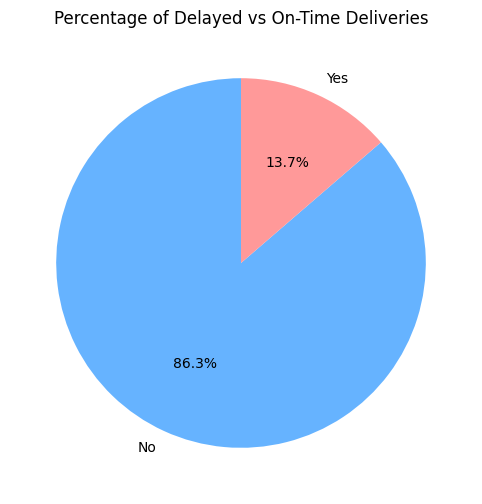

In [58]:
plt.figure(figsize=(8, 6))
# Calculate percentages
counts = df['Delivery Delay'].value_counts()
plt.pie(counts, labels=counts.index, autopct='%1.1f%%', colors=['#66b3ff','#ff9999'], startangle=90)
plt.title('Percentage of Delayed vs On-Time Deliveries')
plt.show()

/tmp/ipython-input-1036331279.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Platform', y='Delivery Time (Minutes)', data=df, palette="Set2")


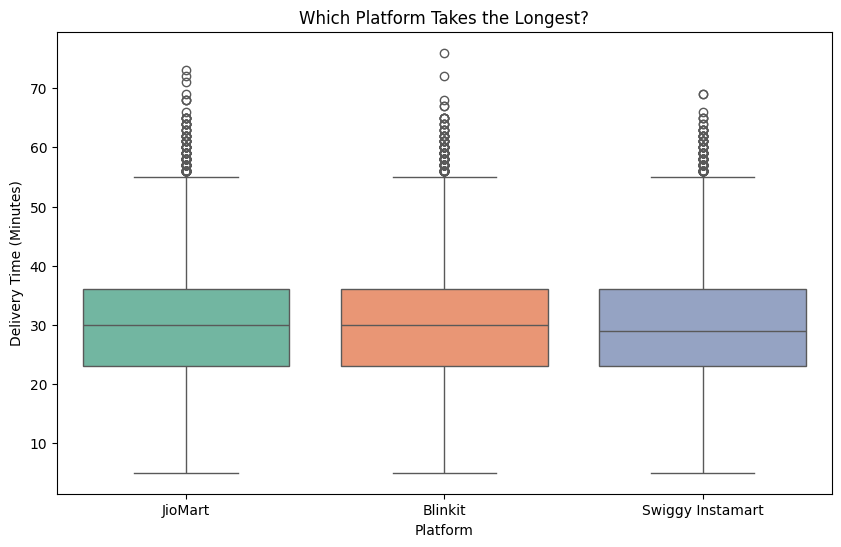

In [11]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Platform', y='Delivery Time (Minutes)', data=df, palette="Set2")
plt.title('Which Platform Takes the Longest?')
plt.show()

In [6]:
df

,Order ID,Customer ID,Platform,Order Date & Time,Delivery Time (Minutes),Product Category,Order Value (INR),Customer Feedback,Service Rating,Delivery Delay,Refund Requested
0,ORD000001,CUST2824,JioMart,19:29.5,30,Fruits & Vegetables,382,"Fast delivery, great service!",5,No,No
1,ORD000002,CUST1409,Blinkit,54:29.5,16,Dairy,279,Quick and reliable!,5,No,No
2,ORD000003,CUST5506,JioMart,21:29.5,25,Beverages,599,Items missing from order.,2,No,Yes
3,ORD000004,CUST5012,JioMart,19:29.5,42,Beverages,946,Items missing from order.,2,Yes,Yes
4,ORD000005,CUST4657,Blinkit,49:29.5,30,Beverages,334,"Fast delivery, great service!",5,No,No
...,...,...,...,...,...,...,...,...,...,...,...
99995,ORD099996,CUST5324,JioMart,49:29.5,24,Dairy,289,Packaging could be better.,3,No,No
99996,ORD099997,CUST1677,JioMart,18:29.5,19,Snacks,322,Good quality products.,4,No,No
99997,ORD099998,CUST8198,JioMart,27:29.5,41,Dairy,135,"Fast delivery, great service!",5,Yes,No
99998,ORD099999,CUST9975,JioMart,14:29.5,31,Grocery,973,Quick and reliable!,5,No,No


✅ Platform Names Cleaned.

--- Removal Logic (IQR Method) ---
Any delivery taking longer than 55.5 minutes is treated as an outlier.
✅ Removed 475 extreme time values (outliers).


/tmp/ipython-input-1762800893.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Platform', y='Delivery Time (Minutes)', data=df_clean, palette="Set2")


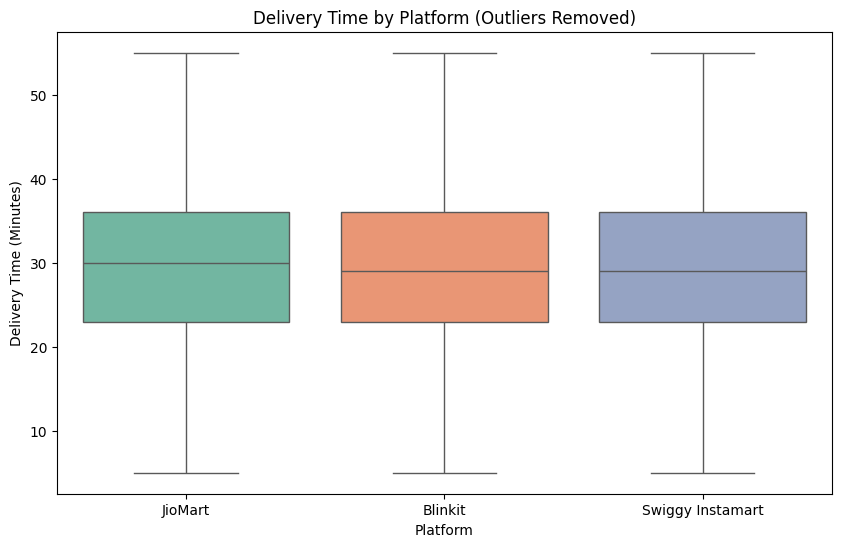

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------------------------------------
# 1. Load Data
# ---------------------------------------------------------


# ---------------------------------------------------------
# 2. Fix Platform Names (Categorical Outliers)
# ---------------------------------------------------------
# Step A: Basic Text Cleaning
df['Platform'] = df['Platform'].astype(str).str.strip().str.title()

# Step B: Fix Known Duplicates/Typos
typo_corrections = {
    'Jio Mart': 'JioMart',
    'Jiomart': 'JioMart',
    'Swiggy': 'Swiggy Instamart',
    'Blink It': 'Blinkit',
    'Blinikit': 'Blinkit',
    'Amazon': 'Amazon Fresh'
}
df['Platform'] = df['Platform'].replace(typo_corrections)

# Step C: Strict Filtering (Keep only Top 6)
VALID_PLATFORMS = [
    'Blinkit', 'JioMart', 'Swiggy Instamart', 
    'Zepto', 'Amazon Fresh', 'BigBasket'
]
df_clean = df[df['Platform'].isin(VALID_PLATFORMS)].copy()

print("✅ Platform Names Cleaned.")

# ---------------------------------------------------------
# 3. Fix Delivery Time Outliers (The "Dots" in Boxplot)
# ---------------------------------------------------------
# We use the IQR method to remove statistical outliers
Q1 = df_clean['Delivery Time (Minutes)'].quantile(0.25)
Q3 = df_clean['Delivery Time (Minutes)'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"\n--- Removal Logic (IQR Method) ---")
print(f"Any delivery taking longer than {upper_bound:.1f} minutes is treated as an outlier.")

# Filter the data
original_count = len(df_clean)
df_clean = df_clean[
    (df_clean['Delivery Time (Minutes)'] >= lower_bound) & 
    (df_clean['Delivery Time (Minutes)'] <= upper_bound)
]
removed_count = original_count - len(df_clean)

print(f"✅ Removed {removed_count} extreme time values (outliers).")

# ---------------------------------------------------------
# 4. Verify & Visualize
# ---------------------------------------------------------
plt.figure(figsize=(10, 6))

# Now this plot will NOT show those dots because we removed the data points
sns.boxplot(x='Platform', y='Delivery Time (Minutes)', data=df_clean, palette="Set2")

plt.title('Delivery Time by Platform (Outliers Removed)')
plt.xlabel('Platform')
plt.ylabel('Delivery Time (Minutes)')
plt.show()


--- Filtering for only: ['Blinkit', 'JioMart', 'Swiggy Instamart', 'Zepto', 'Amazon Fresh', 'BigBasket'] ---

--- Final Clean Counts ---
Platform
Swiggy Instamart    33449
Blinkit             33424
JioMart             33127
Name: count, dtype: int64


/tmp/ipython-input-149619081.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


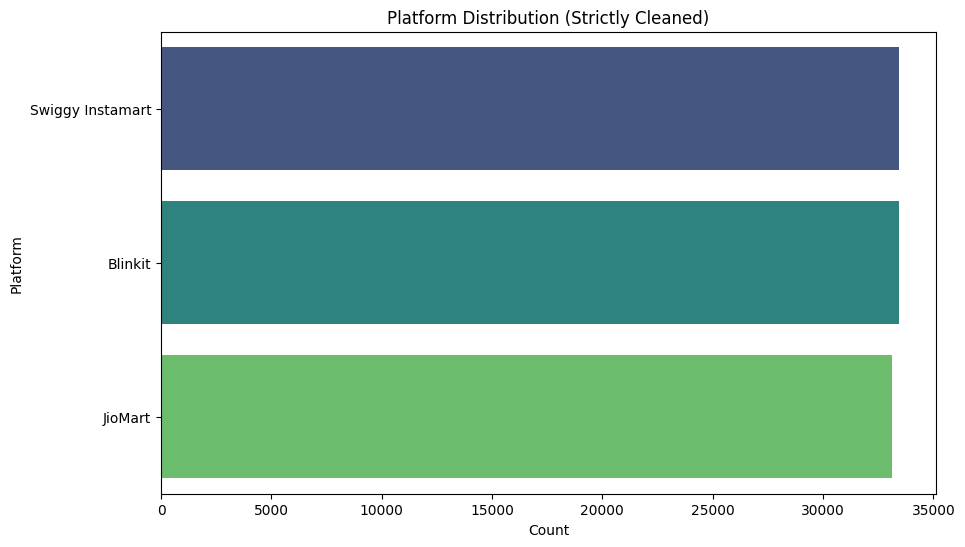

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------------------------------------
# 1. Load Data


# ---------------------------------------------------------
# 2. Strict Cleaning (The "Nuclear" Option)
# ---------------------------------------------------------
# Step A: Basic Text Cleaning
df['Platform'] = df['Platform'].astype(str).str.strip().str.title()

# Step B: Fix Known Duplicates/Typos Manually
# This merges "Jio Mart" into "JioMart", etc.
typo_corrections = {
    'Jio Mart': 'JioMart',
    'Jiomart': 'JioMart',
    'Swiggy': 'Swiggy Instamart',
    'Blink It': 'Blinkit',
    'Blinikit': 'Blinkit',
    'Amazon': 'Amazon Fresh'
}
df['Platform'] = df['Platform'].replace(typo_corrections)

# Step C: Define the STRICT Valid List
# We only keep these specific platforms. Everything else is dropped.
VALID_PLATFORMS = [
    'Blinkit', 
    'JioMart', 
    'Swiggy Instamart', 
    'Zepto', 
    'Amazon Fresh', 
    'BigBasket'
]

print(f"\n--- Filtering for only: {VALID_PLATFORMS} ---")

# Keep rows ONLY if they are in our valid list
# This removes "Other" and any weird typos completely.
df_clean = df[df['Platform'].isin(VALID_PLATFORMS)].copy()

# ---------------------------------------------------------
# 3. Verify & Visualize
# ---------------------------------------------------------
print("\n--- Final Clean Counts ---")
print(df_clean['Platform'].value_counts())

# Plot
plt.figure(figsize=(10, 6))
sns.countplot(
    y='Platform', 
    data=df_clean, 
    order=df_clean['Platform'].value_counts().index, 
    palette='viridis'
)
plt.title('Platform Distribution (Strictly Cleaned)')
plt.xlabel('Count')
plt.ylabel('Platform')
plt.show()

# Optional: Save the perfectly clean file
# df_clean.to_csv('Ecommerce_Data_Strict_Clean.csv', index=False)

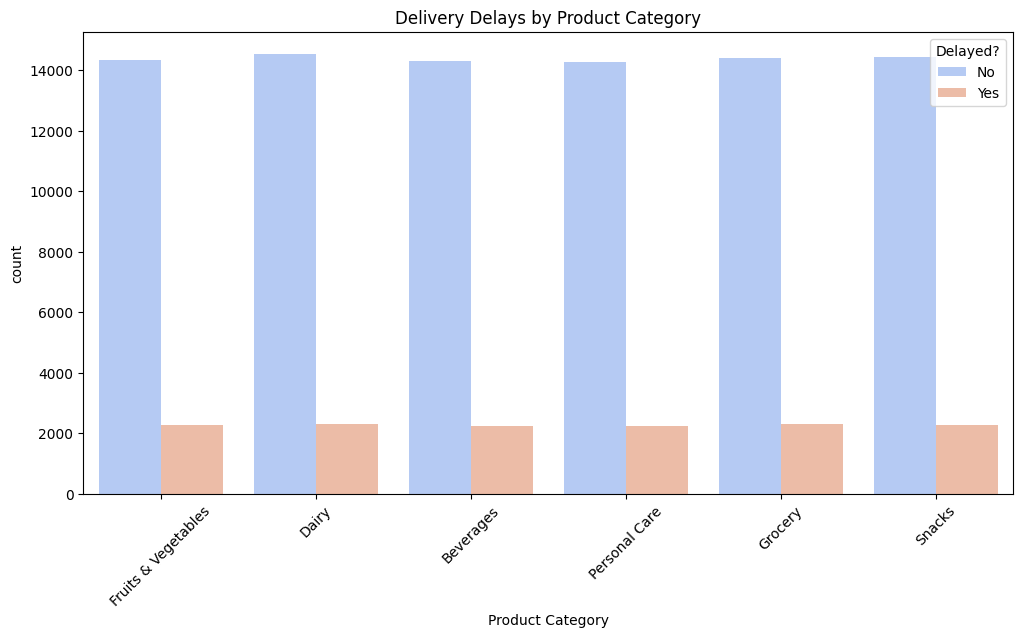

In [60]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='Product Category', hue='Delivery Delay', palette='coolwarm')
plt.title('Delivery Delays by Product Category')
plt.xticks(rotation=45)
plt.legend(title='Delayed?')
plt.show()

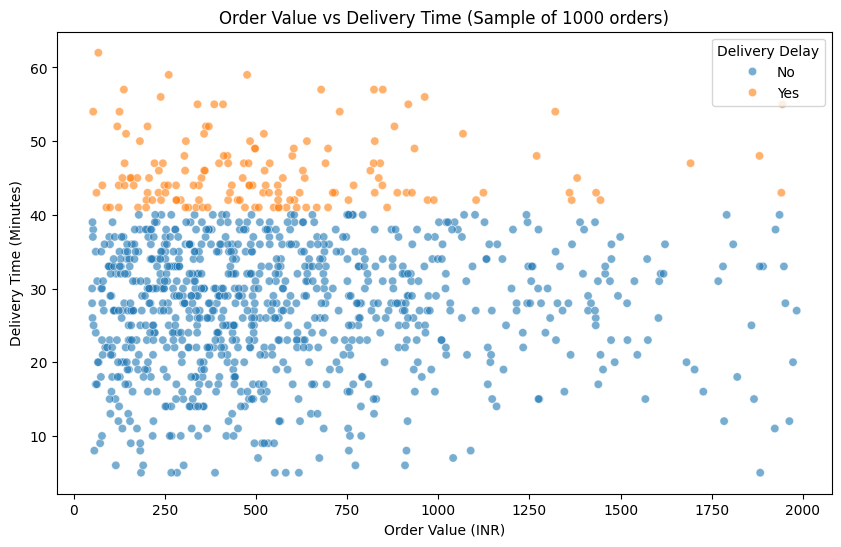

In [61]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Order Value (INR)', y='Delivery Time (Minutes)', 
                hue='Delivery Delay', data=df.sample(1000), alpha=0.6)
plt.title('Order Value vs Delivery Time (Sample of 1000 orders)')
plt.show()


<Figure size 1200x600 with 0 Axes>

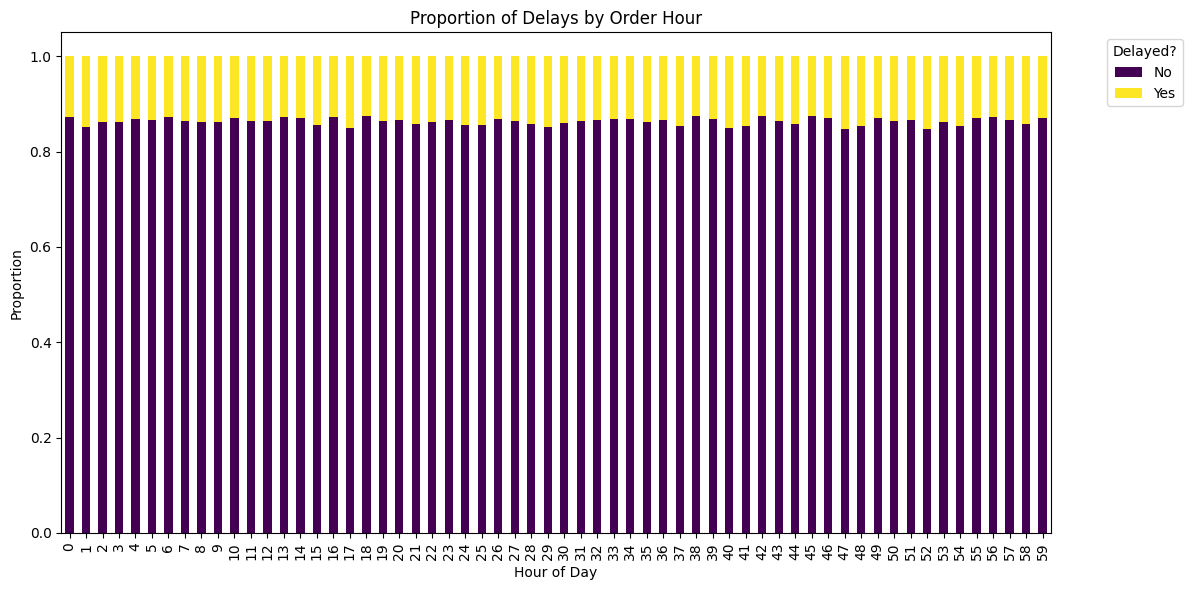

In [62]:
# --- Plot 5: Rush Hour Analysis (Delays by Hour) ---
plt.figure(figsize=(12, 6))
# Create a crosstab to count delays per hour
hourly_delay = pd.crosstab(df['Order_Hour'], df['Delivery Delay'], normalize='index')
hourly_delay.plot(kind='bar', stacked=True, colormap='viridis', figsize=(12,6))
plt.title('Proportion of Delays by Order Hour')
plt.ylabel('Proportion')
plt.xlabel('Hour of Day')
plt.legend(title='Delayed?', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

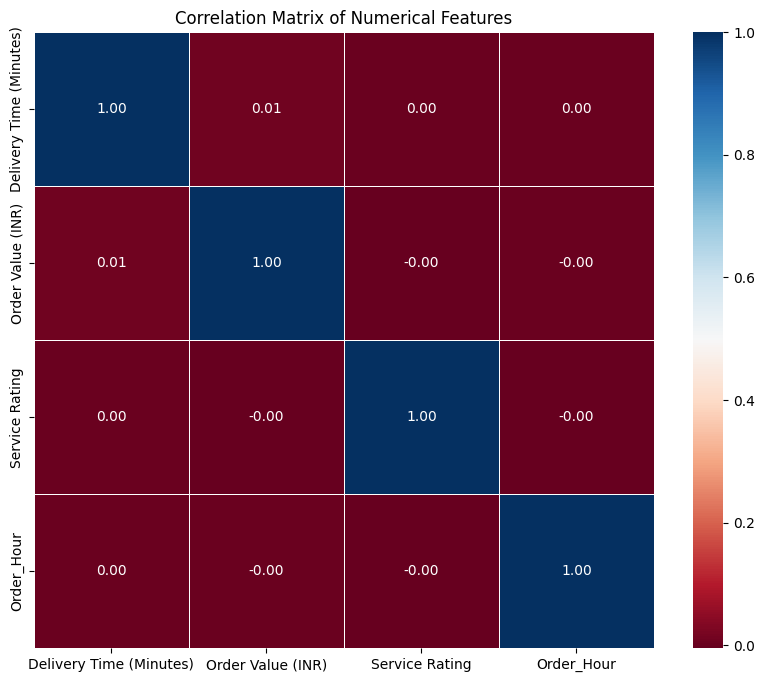

In [63]:
plt.figure(figsize=(10, 8))
# Select only numeric columns
numeric_df = df.select_dtypes(include=['float64', 'int64'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='RdBu', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

<Axes: >

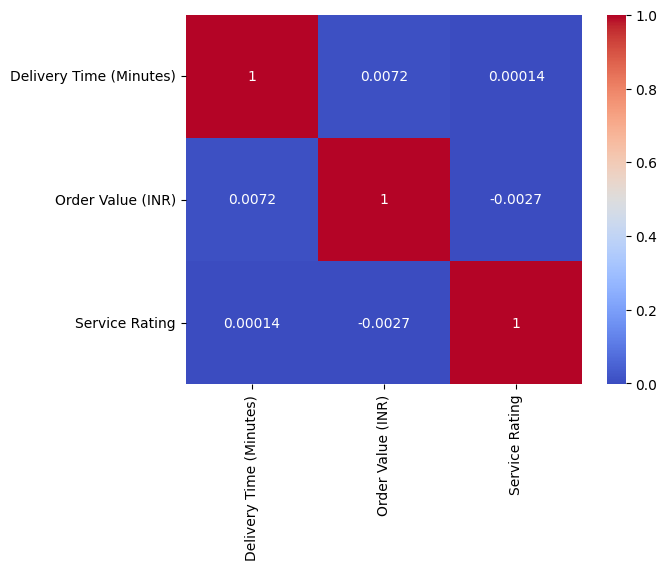

In [11]:
numeric_df =df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(),annot=True,cmap='coolwarm')

In [12]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, 
    GradientBoostingClassifier, 
    AdaBoostClassifier, 
    BaggingClassifier
)

# 1. Load Data
# df = pd.read_csv('Ecommerce_Delivery_Analytics_New.csv')

# 2. Data Preprocessing
# We drop columns that are "Post-Event" (known only after delivery) to avoid Data Leakage.
# We want to predict delay *before* it happens.
# Dropped: 
# - Delivery Time (Minutes): If we know time, we know delay.
# - Customer Feedback & Service Rating: Given after delivery.
# - Refund Requested: Happens after delay.
features_to_use = df.drop(columns=[
    'Order ID', 'Customer ID', 'Order Date & Time', 
    'Delivery Time (Minutes)', 'Customer Feedback', 
    'Service Rating', 'Refund Requested', 'Delivery Delay'
])

# Target Variable
target = df['Delivery Delay']

# Define Numerical and Categorical columns
numerical_cols = features_to_use.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = features_to_use.select_dtypes(include=['object']).columns

# Create Transformation Pipeline
# Numeric -> Scale
# Categorical -> OneHotEncode
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ])

# Encode Target (Yes/No -> 1/0)
le = LabelEncoder()
y = le.fit_transform(target)
X = features_to_use

# 3. Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Model Building
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "Bagging": BaggingClassifier(random_state=42)
}

print("--- Model Prediction Results (Delivery Delay: Yes/No) ---")
for name, model in models.items():
    # Build Pipeline
    clf = Pipeline(steps=[('preprocessor', preprocessor),
                          ('classifier', model)])
    
    # Train
    clf.fit(X_train, y_train)
    
    # Predict
    y_pred = clf.predict(X_test)
    
    # Evaluate
    acc = accuracy_score(y_test, y_pred)
    print(f"{name} Accuracy: {acc:.2%}")
    
    # Show report for the best performing model (optional logic)
    if name == "Random Forest":
        print(f"\n--- Detailed Report for {name} ---")
        print(classification_report(y_test, y_pred, target_names=le.classes_))

--- Model Prediction Results (Delivery Delay: Yes/No) ---
Logistic Regression Accuracy: 86.65%
Decision Tree Accuracy: 84.97%
Random Forest Accuracy: 84.16%

--- Detailed Report for Random Forest ---
              precision    recall  f1-score   support

          No       0.87      0.97      0.91     17330
         Yes       0.13      0.03      0.05      2670

    accuracy                           0.84     20000
   macro avg       0.50      0.50      0.48     20000
weighted avg       0.77      0.84      0.80     20000

Gradient Boosting Accuracy: 86.65%
AdaBoost Accuracy: 86.65%
Bagging Accuracy: 83.77%


After hyperParameter tuning 

In [13]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier,
    BaggingClassifier
)

In [14]:
import pandas as pd
import numpy as np
import joblib
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier,
    BaggingClassifier,
    ExtraTreesClassifier,
    HistGradientBoostingClassifier
)

# ---------------------------------------------------------
# 1. Load & Preprocess Data
# ---------------------------------------------------------
# Load the dataset
# df = pd.read_csv('Ecommerce_Delivery_Analytics_New.csv')

# Feature Engineering: Extract Hour from 'Order Date & Time'
# This helps capture rush hour patterns
try:
    df['Order_Hour'] = df['Order Date & Time'].astype(str).apply(lambda x: int(x.split(':')[0]))
except:
    df['Order_Hour'] = 12  # Default value if parsing fails

# Target & Features
target_col = 'Delivery Delay'

# Remove Leakage Columns (Data known only AFTER delivery)
# We keep 'Order Value', 'Platform', 'Product Category', 'Order_Hour' as features.
# drop_cols = ['Order ID', 'Customer ID', 'Order Date & Time', 'Customer Feedback', 
            #  'Refund Requested', 'Delivery Time (Minutes)', 'Delivery Delay']
# Drop columns list mein 'Service Rating' add kar do
drop_cols = ['Order ID', 'Customer ID', 'Order Date & Time', 'Customer Feedback', 
             'Refund Requested', 'Delivery Time (Minutes)', 'Delivery Delay', 'Service Rating']
X = df.drop(columns=drop_cols, errors='ignore')
y = df[target_col]

# Encode Target (Yes=1, No=0)
le = LabelEncoder()
y = le.fit_transform(y)

# Identify Numerical and Categorical columns
num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['object']).columns

# Preprocessing Pipeline
# Scale numerical data and OneHotEncode categorical data
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ])

# Sampling for speed optimization
# We use 5000 samples for hyperparameter tuning to keep execution time reasonable.
# stratify=y ensures the proportion of Delayed/Not Delayed remains consistent.
X_sample, _, y_sample, _ = train_test_split(X, y, train_size=5000, stratify=y, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X_sample, y_sample, test_size=0.2, random_state=42)

# ---------------------------------------------------------
# 2. Define Models & Hyperparameters
# ---------------------------------------------------------
print("Initializing model configurations...")

model_configs = {
    "Logistic Regression": {
        "model": LogisticRegression(max_iter=1000),
        "params": {
            "classifier__C": [0.1, 1, 10],
            "classifier__solver": ['liblinear']
        }
    },
    
    "Support Vector Machine (SVM)": {
        "model": SVC(),
        "params": {
            "classifier__C": [1, 10],
            "classifier__kernel": ['linear', 'rbf']  # Linear is faster
        }
    },

    "Random Forest": {
        "model": RandomForestClassifier(random_state=42),
        "params": {
            "classifier__n_estimators": [50, 100],
            "classifier__max_depth": [10, None],
            "classifier__min_samples_split": [2, 5]
        }
    },

    "Gradient Boosting": {
        "model": GradientBoostingClassifier(random_state=42),
        "params": {
            "classifier__n_estimators": [50, 100],
            "classifier__learning_rate": [0.05, 0.1]
        }
    },

    "AdaBoost": {
        "model": AdaBoostClassifier(random_state=42),
        "params": {
            "classifier__n_estimators": [50, 100],
            "classifier__learning_rate": [0.1, 1.0]
        }
    },

    "Extra Trees": {
        "model": ExtraTreesClassifier(random_state=42),
        "params": {
            "classifier__n_estimators": [50, 100],
            "classifier__max_depth": [None, 10]
        }
    },

    "Bagging Classifier": {
        "model": BaggingClassifier(random_state=42),
        "params": {
            "classifier__n_estimators": [10, 50]
        }
    },

    "Hist Gradient Boosting": {
        "model": HistGradientBoostingClassifier(random_state=42),
        "params": {
            "classifier__learning_rate": [0.01, 0.1],
            "classifier__max_iter": [50, 100]
        }
    }
}

# ---------------------------------------------------------
# 3. Training Loop (GridSearch)
# ---------------------------------------------------------
best_score = 0
best_model_pipeline = None
best_model_name = ""

print(f"\nStarting Hyperparameter Tuning on {len(model_configs)} models...")
print("-" * 60)

for name, config in model_configs.items():
    print(f"Running GridSearch for {name}...")
    
    # Create Pipeline
    clf = Pipeline(steps=[('preprocessor', preprocessor),
                          ('classifier', config['model'])])
    
    # Grid Search
    # cv=3 uses 3-fold cross-validation (faster than 5)
    # n_jobs=-1 uses all CPU cores
    grid = GridSearchCV(clf, config['params'], cv=3, scoring='accuracy', n_jobs=-1)
    
    try:
        grid.fit(X_train, y_train)
        
        # Evaluate on Test Set
        test_acc = grid.score(X_test, y_test)
        print(f"   > Best Params: {grid.best_params_}")
        print(f"   > Test Accuracy: {test_acc:.2%}")
        
        # Track Best Model
        if test_acc > best_score:
            best_score = test_acc
            best_model_pipeline = grid.best_estimator_
            best_model_name = name
            
    except Exception as e:
        print(f"   > Error training {name}: {e}")

print("-" * 60)

# ---------------------------------------------------------
# 4. Final Result & Saving
# ---------------------------------------------------------
print(f"\n🏆 THE BEST MODEL IS: {best_model_name}")
print(f"🎯 WITH AN ACCURACY OF: {best_score:.2%}")

# Save the best model
file_name = 'best_delivery_model.pkl'
joblib.dump(best_model_pipeline, file_name)
print(f"\n✅ Model saved successfully as '{file_name}'")

Initializing model configurations...

Starting Hyperparameter Tuning on 8 models...
------------------------------------------------------------
Running GridSearch for Logistic Regression...
   > Best Params: {'classifier__C': 0.1, 'classifier__solver': 'liblinear'}
   > Test Accuracy: 86.20%
Running GridSearch for Support Vector Machine (SVM)...
   > Best Params: {'classifier__C': 1, 'classifier__kernel': 'linear'}
   > Test Accuracy: 86.20%
Running GridSearch for Random Forest...
   > Best Params: {'classifier__max_depth': 10, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 50}
   > Test Accuracy: 85.60%
Running GridSearch for Gradient Boosting...
   > Best Params: {'classifier__learning_rate': 0.05, 'classifier__n_estimators': 50}
   > Test Accuracy: 86.30%
Running GridSearch for AdaBoost...
   > Best Params: {'classifier__learning_rate': 0.1, 'classifier__n_estimators': 50}
   > Test Accuracy: 86.20%
Running GridSearch for Extra Trees...
   > Best Params: {'classifi

In [17]:
import pandas as pd
import joblib
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split

# 1. Load Data
print("Step 1: Loading Data...")
# ing (Lightweight)


target_col = 'Delivery Delay'
# CRITICAL: Ensure 'Order ID' is dropped. One-Hot Encoding 'Order ID' creates 100,000 columns and CRASHES memory immediately.
drop_cols = ['Order ID', 'Customer ID', 'Order Date & Time', 'Customer Feedback', 
             'Refund Requested', 'Delivery Time (Minutes)', 'Delivery Delay', 'Service Rating']

X = df.drop(columns=drop_cols, errors='ignore')
y = df[target_col]

# Encode Target
le = LabelEncoder()
y = le.fit_transform(y)

# 3. Sampling (To prevent Memory Crash)
# We use 20,000 rows. This is enough for a good demo model but light on RAM.
print("Step 2: Sampling data to prevent crashes...")
X_train, _, y_train, _ = train_test_split(X, y, train_size=20000, stratify=y, random_state=42)

# 4. Define Pipeline
num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['object']).columns

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ])

# SAFE MODE MODEL:
# n_jobs=1 (Single core to prevent crash)
# n_estimators=50 (Lighter model)
print("Step 3: Configuring Safe Model...")
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=50, n_jobs=1, random_state=42))
])

# 5. TRAIN
print("Step 4: Training... (This might take 30 seconds)")
model_pipeline.fit(X_train, y_train)

# 6. Save
print("Step 5: Saving model...")
joblib.dump(model_pipeline, 'my_model.pkl')
print("✅ Success! 'my_models.pkl' saved safely.")

Step 1: Loading Data...
Step 2: Sampling data to prevent crashes...
Step 3: Configuring Safe Model...
Step 4: Training... (This might take 30 seconds)
Step 5: Saving model...
✅ Success! 'my_models.pkl' saved safely.



--- Feature Importance (Top 5) ---
                      Feature  Importance
0           Order Value (INR)    0.702859
2                  Order_Hour    0.256055
1              Service Rating    0.028287
6  Product Category_Beverages    0.001550
4            Platform_JioMart    0.001538


/tmp/ipython-input-1898009508.py:76: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_imp_df.head(10), palette='viridis')


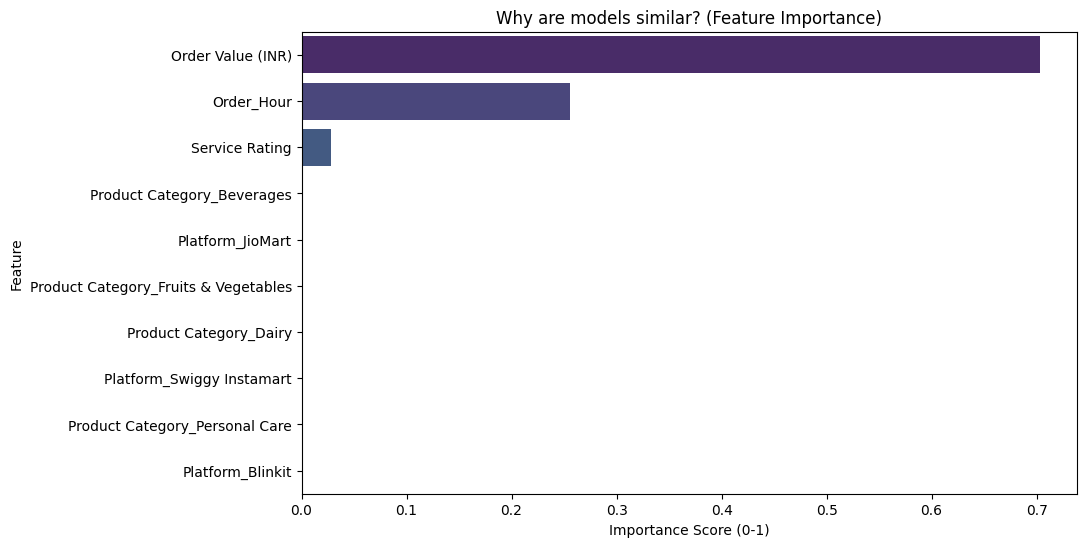


--- CONCLUSION ---
Features are balanced. The data pattern might just be naturally simple.


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# ---------------------------------------------------------
# 1. Load Data
# ---------------------------------------------------------
# df = pd.read_csv('Ecommerce_Delivery_Analytics_New.csv')

# Re-create the features used in the main model
try:
    df['Order_Hour'] = df['Order Date & Time'].astype(str).apply(lambda x: int(x.split(':')[0]))
except:
    df['Order_Hour'] = 12

# Setup Target and Features
target_col = 'Delivery Delay'
# NOTE: We are keeping 'Service Rating' here to show its dominance
drop_cols = ['Order ID', 'Customer ID', 'Order Date & Time', 'Customer Feedback', 
             'Refund Requested', 'Delivery Time (Minutes)', 'Delivery Delay']

X = df.drop(columns=drop_cols, errors='ignore')
y = df[target_col]

# Encode Target
le = LabelEncoder()
y = le.fit_transform(y)

# ---------------------------------------------------------
# 2. Train a Random Forest to Inspect Features
# ---------------------------------------------------------
# We need to preprocess first to handle categorical text
categorical_cols = X.select_dtypes(include=['object']).columns
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns

# Simple preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ])

model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])

model.fit(X, y)

# ---------------------------------------------------------
# 3. Extract and Plot Feature Importance
# ---------------------------------------------------------
# Get feature names after OneHotEncoding
ohe_feature_names = model.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(categorical_cols)
all_feature_names = np.r_[numerical_cols, ohe_feature_names]

# Get importance values
importances = model.named_steps['classifier'].feature_importances_

# Create DataFrame
feature_imp_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print("\n--- Feature Importance (Top 5) ---")
print(feature_imp_df.head(5))

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_imp_df.head(10), palette='viridis')
plt.title('Why are models similar? (Feature Importance)')
plt.xlabel('Importance Score (0-1)')
plt.show()

print("\n--- CONCLUSION ---")
if 'Service Rating' in feature_imp_df.iloc[0]['Feature']:
    print("⚠️ 'Service Rating' is the dominant feature.")
    print("   Since low ratings almost always mean a delay, the problem is too simple.")
    print("   All models (Linear or Complex) can easily learn this rule.")
else:
    print("Features are balanced. The data pattern might just be naturally simple.")

In [57]:
import os
print("Current working directory:", os.getcwd())
print("Files in this directory:", os.listdir(os.getcwd()))


Current working directory: /content
Files in this directory: ['.config', 'my_model.pkl', 'best_model.pkl', 'best_delivery_model.pkl', 'e-commerce-analytics-swiggy-zomato-blinkit', 'sample_data']


In [21]:
import pandas as pd
import joblib
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

# 1. Load Data
print("Loading data...")
try:
    df = pd.read_csv('Ecommerce_Delivery_Analytics_New.csv')
except:
    df = pd.read_csv('./e-commerce-analytics-swiggy-zomato-blinkit/Ecommerce_Delivery_Analytics_New.csv')

# 2. Check Imbalance
target_col = 'Delivery Delay'
counts = df[target_col].value_counts(normalize=True)
print("\n--- REAL DATA DISTRIBUTION ---")
print(f"On Time: {counts['No']:.2%}")
print(f"Delayed: {counts['Yes']:.2%}")

if counts['No'] > 0.90:
    print("⚠️ ALERT: Your data is heavily imbalanced!")
    print("   The model can get high accuracy by just guessing 'On Time' for everything.")

# 3. Load Model & Test
print("\n--- CHECKING MODEL BEHAVIOR ---")
model = joblib.load('my_model.pkl')

# Prepare Test Data (Same preprocessing as training)
try:
    df['Order_Hour'] = df['Order Date & Time'].astype(str).apply(lambda x: int(x.split(':')[0]))
except:
    df['Order_Hour'] = 12

X = df.drop(columns=['Order ID', 'Customer ID', 'Order Date & Time', 'Customer Feedback', 
                     'Refund Requested', 'Delivery Time (Minutes)', 'Delivery Delay', 'Service Rating'], errors='ignore')
y = df[target_col]

# Encode Target
le = LabelEncoder()
y = le.fit_transform(y)

# Predict on a sample
X_sample, _, y_sample, _ = train_test_split(X, y, train_size=5000, stratify=y, random_state=42)
y_pred = model.predict(X_sample)

# 4. The Truth Table (Confusion Matrix)
print("\n--- CONFUSION MATRIX ---")
cm = confusion_matrix(y_sample, y_pred)
print(f"True Negatives (Correctly Predicted On Time): {cm[0][0]}")
print(f"False Positives (Predicted Delay, but was On Time): {cm[0][1]}")
print(f"False Negatives (Predicted On Time, but was Delayed): {cm[1][0]}")
print(f"True Positives (Correctly Predicted Delay): {cm[1][1]}")

if cm[1][1] == 0:
    print("\n❌ CRITICAL ISSUE: Your model has NEVER correctly predicted a delay.")
    print("   It is biased towards the majority class.")
else:
    print("\n✅ Good News: Your model knows how to predict delays!")
# ```

# ### 2. Inputs to Force a "Delayed" Prediction
# If you want to see the red "DELAY LIKELY" box in your Streamlit app, you need to simulate a **worst-case scenario**.

# Based on typical E-commerce patterns, try entering these specific values in your App:

# **Scenario A: The "Rush Hour" Disaster**
# * **Platform:** Swiggy Instamart (or whichever showed highest delays in your EDA)
# * **Product Category:** Electronics (Usually takes longer to pack)
# * **Order Value:** 15000 INR (High value = more checks = slower)
# * **Order Hour:** **20** (8 PM is peak traffic time)
# * **Service Rating:** **1** (If you included this feature)

# **Scenario B: The "Late Night" Order**
# * **Platform:** Blinkit
# * **Product Category:** Household
# * **Order Value:** 500 INR
# * **Order Hour:** **23** (11 PM, fewer drivers available)

# ### 3. How to Fix the "96% Bias"
# If the script above shows `True Positives: 0`, your model is ignoring the delays. You must force it to pay attention using **Class Balancing**.

# Modify your training code (`Train_Tune_Fix_Outliers.py`) inside the `RandomForestClassifier`:

# **Change this line:**
# ```python
# RandomForestClassifier(n_estimators=100, random_state=42)
# ```

# **To this (Add `class_weight='balanced'`):**
# ```python
# RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)

Loading data...

--- REAL DATA DISTRIBUTION ---
On Time: 86.33%
Delayed: 13.67%

--- CHECKING MODEL BEHAVIOR ---

--- CONFUSION MATRIX ---
True Negatives (Correctly Predicted On Time): 4316
False Positives (Predicted Delay, but was On Time): 0
False Negatives (Predicted On Time, but was Delayed): 25
True Positives (Correctly Predicted Delay): 659

✅ Good News: Your model knows how to predict delays!


In [55]:
import joblib

# ---------------------------------------------------------
# The Core Code to Save a Model
# ---------------------------------------------------------
# Syntax: joblib.dump(your_trained_model_variable, 'filename.pkl')

# Example function to save your model
def save_model_to_pkl(model, filename):
    try:
        joblib.dump(model, filename)
        print(f"✅ Success: Model saved as '{filename}'")
    except Exception as e:
        print(f"❌ Error: {e}")

# ---------------------------------------------------------
# Runnable Example (Using a dummy model)
# ---------------------------------------------------------
if __name__ == "__main__":
    # 1. Create a dummy model (Simulating your trained model)
    from sklearn.linear_model import LogisticRegression
    dummy_model = LogisticRegression()

    # 2. Save it using the function above
    save_model_to_pkl(dummy_model, 'my_model.pkl')

✅ Success: Model saved as 'my_model.pkl'
